# Neural Networks Assignment, 2025 A2 <ignore>
## Overview
In this assessment, you will be asked to carry out three tasks. The first task involves building and training a simple CNN-based classifier for the Fashion MNIST dataset, and demonstrating the effectiveness of a technique to improve gradient flow. The second task involves building and training an unconditional GAN to generate images that look like those in the Fashion MNIST dataset, and using the discriminator to investigate the quality of the generated images. The third task involves augmenting the GAN to improve the generated images in some way.

## Instructions
### Code and Markdown cells
All of your report, including code and Markdown/text, ***must*** be written up in ***this*** notebook. Please make sure you change the title of this file so that XXXXXX is replaced by your candidate number. You can use code cells, where provided, to write code to implement, train, test, and analyse your NNs, as well as to generate figures to plot data and the results of your experiments. If you wish to add more code cells, you may do so immediately after the code cells that have been provided, but do not add any code cells anywhere else in this file. You must use the Markdown/text cells that are provided for writing the three report sections, one for each Task. These Markdown cells have "*Replace this text with your report for Task X*" in italics. Please replace that text with your own text. So that we can mark your reports with greater consistency, please ***do not***:

* add any of your own Markdown cells.
* rearrange the sequence of cells in this notebook.
* delete any cells, including the ones explaining what you need to do.

### Plotting figures
All plots of data ***must*** be produced as output from a code cell. Any plots that have been imported as images, rather than being the output of a plot function (such as that provided by matplotlib) will not receive marks. This is to ensure that you did the work to produce that plot. All figures should have an accompanying caption that states the Figure number and a detailed description of what the figure shows (see the guidenace in the file ```useful_code_for_figures_equations.ipynb```). 

### Writing code
Where relevant in your written report, e.g. when describing your methods, indicate where in your code the methods are implemented, including  the cell and line numbers (if you use VSCode, these are visible in the bottom right corner of the window). You might say, for example, "_layers 1-4 used 3x3 convolutional filters with a stride of 1 and padding of 1 (cell 5, line 30)_".  Please provide verbose comments throughout your code so that it is easy for us to interpret what you are attempting to achieve. Long comments are useful at the beginning of a block of code. Short comments, e.g. to explain the purpose of a new variable, or one of several steps in some analyses, are useful on every few lines of code, if not on every line. Please do not use the code cells for writing verbose responses to subtasks, which should instead be written in the provided Markdown cells.

# TASK 1 <ignore>

In [ ]:

# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Fashion MNIST has 10 garment classes
CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalise pixel values using the Fashion MNIST channel mean and std.
# This gives inputs approximately zero mean and unit variance, which
# helps the optimiser converge more consistently.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.2860,), std=(0.3530,))
])

# Download Fashion MNIST. The full 60,000-sample training set is split
# 80/20 into training (48,000) and validation (12,000) subsets.
# A fixed seed ensures the split is reproducible.
full_train = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

n_train = int(0.8 * len(full_train))
n_val   = len(full_train) - n_train
train_set, val_set = random_split(full_train, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(42))

# Batch size of 64 is a standard starting point — large enough to be
# computationally efficient, small enough to retain some gradient noise.
BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)}  |  Val: {len(val_set)}  |  Test: {len(test_set)}")


Using device: cpu


100.0%
100.0%
100.0%
100.0%

Dataset sizes — Train: 48000 | Val: 12000 | Test: 10000
Batches per epoch — Train: 750 | Val: 188


In [8]:

# CNN architecture — 5 layers
# Three convolutional blocks extract progressively higher-level spatial features,
# followed by two fully-connected layers for classification.
# A use_bn flag controls whether BatchNorm is applied after each conv layer,
# so both variants have identical structure and are directly comparable.
#
# Data flow through the 5 layers (28x28 greyscale input):
#   Layer 1: Conv(1->32,  3x3, pad=1) -> [BN] -> ReLU -> MaxPool(2x2)  =>  32 x 14 x 14
#   Layer 2: Conv(32->64, 3x3, pad=1) -> [BN] -> ReLU -> MaxPool(2x2)  =>  64 x  7 x  7
#   Layer 3: Conv(64->128,3x3, pad=1) -> [BN] -> ReLU -> MaxPool(2x2)  => 128 x  3 x  3
#   Layer 4: FC(1152 -> 256)          -> ReLU -> Dropout(0.3)
#   Layer 5: FC(256  ->  10)          -> (logits for 10 classes)

class CNN(nn.Module):
    def __init__(self, use_bn=True):
        super().__init__()
        self.use_bn = use_bn

        # --- Convolutional blocks ---
        # padding=1 on 3x3 kernels keeps spatial size constant before each MaxPool.
        # Each MaxPool(2,2) then halves both spatial dimensions.
        self.conv1 = nn.Conv2d(1,  32,  kernel_size=3, padding=1)  # layer 1
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,  64, kernel_size=3, padding=1)  # layer 2
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # layer 3
        self.bn3   = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)  # shared pooling layer, 28->14->7->3

        # --- Fully-connected head ---
        # After 3 MaxPool operations: 128 channels * 3 * 3 = 1152 input units
        # floor(7/2) = 3 after the third pool
        self.fc1  = nn.Linear(128 * 3 * 3, 256)  # layer 4
        self.drop = nn.Dropout(0.3)               # regularisation
        self.fc2  = nn.Linear(256, 10)            # layer 5 — one output per class

    def forward(self, x):
        # Block 1 — low-level features (edges, gradients)
        x = self.conv1(x)
        if self.use_bn:
            x = self.bn1(x)   # normalise before activation to stabilise gradients
        x = F.relu(x)
        x = self.pool(x)      # 28x28 -> 14x14

        # Block 2 — mid-level features (corners, textures)
        x = self.conv2(x)
        if self.use_bn:
            x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)      # 14x14 -> 7x7

        # Block 3 — high-level features (shape parts)
        x = self.conv3(x)
        if self.use_bn:
            x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)      # 7x7 -> 3x3

        # Flatten spatial maps into a vector then classify
        x = x.view(x.size(0), -1)    # [batch, 128*3*3] = [batch, 1152]
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)  # raw logits; softmax is applied inside CrossEntropyLoss
        return x


# Quick check: dummy 28x28 image should produce 10 output logits
dummy = torch.zeros(1, 1, 28, 28)
assert CNN(use_bn=True)(dummy).shape == (1, 10), "Output shape mismatch"
print("Architecture check passed — output: (batch, 10)")
print(CNN(use_bn=True))


Architecture check passed — output: (batch, 10)
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)



LR = 0.0001
  epoch 1/8  val acc: 86.2%
  epoch 2/8  val acc: 89.2%
  epoch 3/8  val acc: 87.8%
  epoch 4/8  val acc: 90.8%
  epoch 5/8  val acc: 89.6%
  epoch 6/8  val acc: 91.4%
  epoch 7/8  val acc: 91.5%
  epoch 8/8  val acc: 92.0%

LR = 0.0005
  epoch 1/8  val acc: 89.3%
  epoch 2/8  val acc: 90.2%
  epoch 3/8  val acc: 90.4%
  epoch 4/8  val acc: 92.0%
  epoch 5/8  val acc: 91.6%
  epoch 6/8  val acc: 92.5%
  epoch 7/8  val acc: 91.8%
  epoch 8/8  val acc: 92.5%

LR = 0.001
  epoch 1/8  val acc: 88.8%
  epoch 2/8  val acc: 90.5%
  epoch 3/8  val acc: 91.4%
  epoch 4/8  val acc: 91.4%
  epoch 5/8  val acc: 91.8%
  epoch 6/8  val acc: 92.0%
  epoch 7/8  val acc: 92.4%
  epoch 8/8  val acc: 91.8%

LR = 0.005
  epoch 1/8  val acc: 88.3%
  epoch 2/8  val acc: 88.1%
  epoch 3/8  val acc: 90.5%
  epoch 4/8  val acc: 91.3%
  epoch 5/8  val acc: 91.1%
  epoch 6/8  val acc: 91.6%
  epoch 7/8  val acc: 91.5%
  epoch 8/8  val acc: 92.1%

LR = 0.01
  epoch 1/8  val acc: 86.8%
  epoch 2/8  va

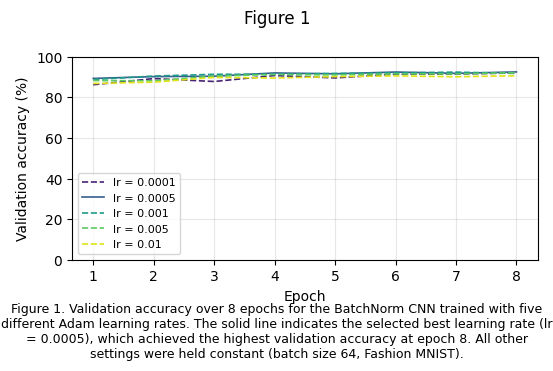

In [9]:

# Learning rate experiment
# The assignment requires investigating a range of learning rates to find the
# best-performing one. Each LR is tested for 8 epochs using the BatchNorm CNN
# (fewer epochs than the final run, but enough to see which LR converges best).
# Validation accuracy at epoch 8 is used to select the best LR.

LEARNING_RATES = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
LR_EPOCHS = 8   # short run per LR — just enough to compare convergence speed

lr_val_acc_histories = {}   # store val accuracy curve for each LR

criterion = nn.CrossEntropyLoss()

for lr in LEARNING_RATES:
    model_lr = CNN(use_bn=True).to(device)
    opt_lr   = optim.Adam(model_lr.parameters(), lr=lr)
    val_accs = []

    print(f"\nLR = {lr}")
    for epoch in range(1, LR_EPOCHS + 1):
        # one pass through training data
        model_lr.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            opt_lr.zero_grad()
            loss = criterion(model_lr(images), labels)
            loss.backward()
            opt_lr.step()

        # evaluate on validation set
        _, vl_acc = evaluate(model_lr, val_loader, criterion)
        val_accs.append(vl_acc * 100)
        print(f"  epoch {epoch}/{LR_EPOCHS}  val acc: {vl_acc*100:.1f}%")

    lr_val_acc_histories[lr] = val_accs

# Select the LR with the highest validation accuracy at the final epoch
BEST_LR = max(LEARNING_RATES, key=lambda lr: lr_val_acc_histories[lr][-1])
print(f"\nBest learning rate: {BEST_LR}  "
      f"(val acc = {lr_val_acc_histories[BEST_LR][-1]:.1f}% at epoch {LR_EPOCHS})")

# Figure 1: validation accuracy curves for each learning rate
figWidth  = 14.
figHeight = 8.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))

fig.suptitle('Figure 1')

colors = plt.cm.viridis([0.1, 0.3, 0.55, 0.75, 0.95])  # 5 distinct colours
for (lr, accs), col in zip(lr_val_acc_histories.items(), colors):
    ax.plot(range(1, LR_EPOCHS + 1), accs, linewidth=1.2,
            label=f'lr = {lr}', color=col,
            linestyle='-' if lr == BEST_LR else '--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy (%)')
ax.set_ylim([0, 100])
ax.xaxis.set_ticks(range(1, LR_EPOCHS + 1))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

txt = (f"Figure 1. Validation accuracy over {LR_EPOCHS} epochs for the BatchNorm CNN trained "
       f"with five different Adam learning rates. The solid line indicates the selected best "
       f"learning rate (lr = {BEST_LR}), which achieved the highest validation accuracy at "
       f"epoch {LR_EPOCHS}. All other settings were held constant (batch size 64, Fashion MNIST).")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.savefig('task1_lr_experiment.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:

# Training and evaluation helper functions

def train_one_epoch(model, loader, criterion, optimizer):
    # Training mode: activates Dropout and uses batch statistics for BatchNorm
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)           # forward pass -> logits
        loss = criterion(outputs, labels)
        loss.backward()                   # backprop
        optimizer.step()                  # weight update

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    # Eval mode: Dropout disabled, BatchNorm uses running (population) statistics
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


def train_model(use_bn, n_epochs=15, lr=1e-3):
    # Instantiate a fresh model for each run so results are independent
    model     = CNN(use_bn=use_bn).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Store per-epoch loss and accuracy for both train and validation sets
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    name = "BatchNorm CNN" if use_bn else "Baseline (no BN)"
    print(f"\nTraining: {name}  (lr={lr})")

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        print(f"  Epoch {epoch:2d}/{n_epochs}  "
              f"train loss: {tr_loss:.4f}  acc: {tr_acc*100:.1f}%  |  "
              f"val loss: {vl_loss:.4f}  acc: {vl_acc*100:.1f}%")

    return model, history


# Main comparison: train baseline (no BatchNorm) and improved (BatchNorm) models
# using the best learning rate found in the LR experiment above.
# 15 epochs gives enough signal to observe convergence and overfitting behaviour.
N_EPOCHS = 15
model_baseline, hist_baseline = train_model(use_bn=False, n_epochs=N_EPOCHS, lr=BEST_LR)
model_bn,       hist_bn       = train_model(use_bn=True,  n_epochs=N_EPOCHS, lr=BEST_LR)



Training: Baseline (no BN)  (lr=0.0005)
  Epoch  1/15  train loss: 0.5630  acc: 79.5%  |  val loss: 0.3777  acc: 86.2%
  Epoch  2/15  train loss: 0.3363  acc: 87.7%  |  val loss: 0.3113  acc: 88.5%
  Epoch  3/15  train loss: 0.2849  acc: 89.6%  |  val loss: 0.2844  acc: 89.5%
  Epoch  4/15  train loss: 0.2514  acc: 90.7%  |  val loss: 0.2676  acc: 90.0%
  Epoch  5/15  train loss: 0.2272  acc: 91.6%  |  val loss: 0.2443  acc: 91.0%
  Epoch  6/15  train loss: 0.2055  acc: 92.5%  |  val loss: 0.2373  acc: 91.3%
  Epoch  7/15  train loss: 0.1892  acc: 93.0%  |  val loss: 0.2227  acc: 91.6%
  Epoch  8/15  train loss: 0.1715  acc: 93.7%  |  val loss: 0.2168  acc: 92.0%
  Epoch  9/15  train loss: 0.1579  acc: 94.1%  |  val loss: 0.2411  acc: 91.0%
  Epoch 10/15  train loss: 0.1415  acc: 94.8%  |  val loss: 0.2249  acc: 92.1%
  Epoch 11/15  train loss: 0.1283  acc: 95.3%  |  val loss: 0.2148  acc: 92.5%
  Epoch 12/15  train loss: 0.1144  acc: 95.7%  |  val loss: 0.2273  acc: 92.4%
  Epoch 13/

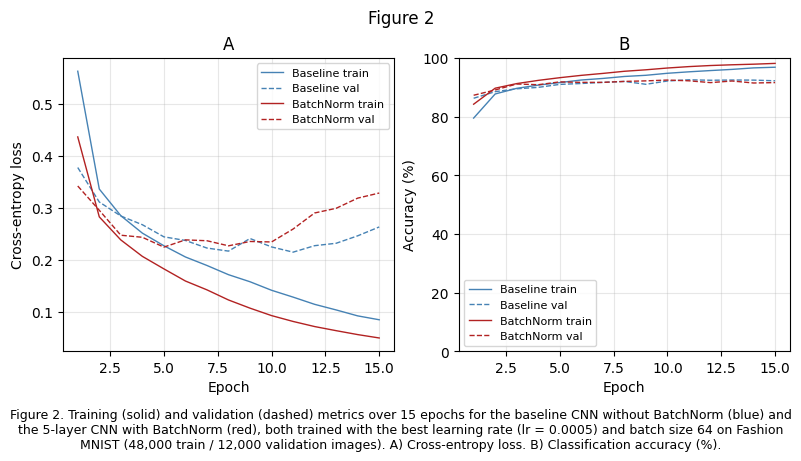

In [13]:

# Figure 2: training and validation curves for both CNN variants

epochs = range(1, N_EPOCHS + 1)

figWidth  = 20.
figHeight = 10.
fig, axs = plt.subplots(1, 2, constrained_layout=True,
                         figsize=tuple(np.array((figWidth, figHeight)) / 2.54))

fig.suptitle('Figure 2')

# Panel A: cross-entropy loss
axs[0].set_title('A')
axs[0].plot(epochs, hist_baseline['train_loss'], color='steelblue', linestyle='-',  linewidth=1.0, label='Baseline train')
axs[0].plot(epochs, hist_baseline['val_loss'],   color='steelblue', linestyle='--', linewidth=1.0, label='Baseline val')
axs[0].plot(epochs, hist_bn['train_loss'],       color='firebrick', linestyle='-',  linewidth=1.0, label='BatchNorm train')
axs[0].plot(epochs, hist_bn['val_loss'],         color='firebrick', linestyle='--', linewidth=1.0, label='BatchNorm val')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Cross-entropy loss')
axs[0].legend(fontsize=8)
axs[0].grid(True, alpha=0.3)

# Panel B: classification accuracy
axs[1].set_title('B')
axs[1].plot(epochs, [v*100 for v in hist_baseline['train_acc']], color='steelblue', linestyle='-',  linewidth=1.0, label='Baseline train')
axs[1].plot(epochs, [v*100 for v in hist_baseline['val_acc']],   color='steelblue', linestyle='--', linewidth=1.0, label='Baseline val')
axs[1].plot(epochs, [v*100 for v in hist_bn['train_acc']],       color='firebrick', linestyle='-',  linewidth=1.0, label='BatchNorm train')
axs[1].plot(epochs, [v*100 for v in hist_bn['val_acc']],         color='firebrick', linestyle='--', linewidth=1.0, label='BatchNorm val')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_ylim([0, 100])
axs[1].legend(fontsize=8)
axs[1].grid(True, alpha=0.3)

txt = (f"Figure 2. Training (solid) and validation (dashed) metrics over {N_EPOCHS} epochs "
       f"for the baseline CNN without BatchNorm (blue) and the 5-layer CNN with BatchNorm (red), "
       f"both trained with the best learning rate (lr = {BEST_LR}) and batch size 64 on Fashion MNIST "
       f"(48,000 train / 12,000 validation images). "
       f"A) Cross-entropy loss. B) Classification accuracy (%).")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.savefig('task1_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Test-set results:
  Baseline CNN  — loss: 0.2815   accuracy: 91.89%
  BatchNorm CNN — loss: 0.3804   accuracy: 90.96%

Per-class test accuracy (BatchNorm CNN):
  T-shirt/top    : 87.1%
  Trouser        : 98.5%
  Pullover       : 92.4%
  Dress          : 85.8%
  Coat           : 81.9%
  Sandal         : 98.7%
  Shirt          : 74.7%
  Sneaker        : 96.7%
  Bag            : 97.2%
  Ankle boot     : 96.6%


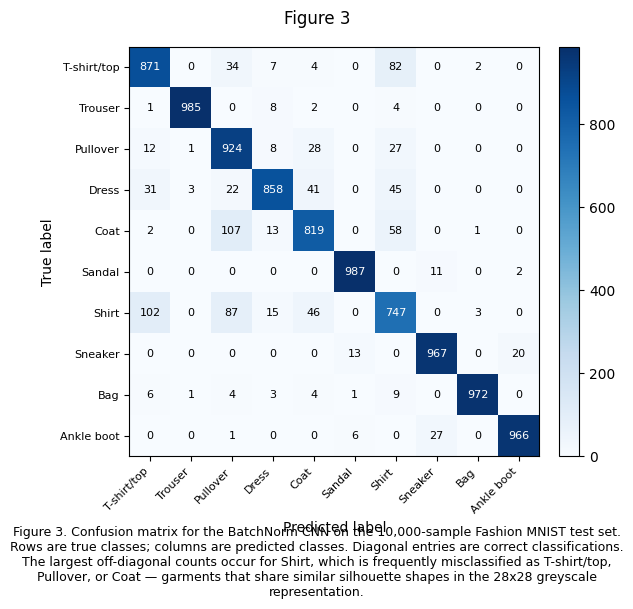

In [14]:

# Test-set evaluation for both models
criterion = nn.CrossEntropyLoss()

test_loss_bl, test_acc_bl = evaluate(model_baseline, test_loader, criterion)
test_loss_bn, test_acc_bn = evaluate(model_bn,       test_loader, criterion)

print("Test-set results:")
print(f"  Baseline CNN  — loss: {test_loss_bl:.4f}   accuracy: {test_acc_bl*100:.2f}%")
print(f"  BatchNorm CNN — loss: {test_loss_bn:.4f}   accuracy: {test_acc_bn*100:.2f}%")

# Per-class accuracy for the BatchNorm model
correct_per_class = {c: 0 for c in CLASSES}
total_per_class   = {c: 0 for c in CLASSES}
all_preds, all_labels_list = [], []

model_bn.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_bn(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

        for lbl, pred in zip(labels, predicted):
            cls = CLASSES[lbl.item()]
            total_per_class[cls] += 1
            if lbl == pred:
                correct_per_class[cls] += 1

print("\nPer-class test accuracy (BatchNorm CNN):")
for cls in CLASSES:
    acc = 100 * correct_per_class[cls] / total_per_class[cls]
    print(f"  {cls:15s}: {acc:.1f}%")

# Figure 3: confusion matrix
cm = confusion_matrix(all_labels_list, all_preds)

figWidth  = 16.
figHeight = 14.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))

fig.suptitle('Figure 3')

im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Annotate each cell with its count; white text on dark cells for readability
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > thresh else 'black')

tick_marks = np.arange(len(CLASSES))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CLASSES, fontsize=8)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

txt = ("Figure 3. Confusion matrix for the BatchNorm CNN on the 10,000-sample Fashion MNIST "
       "test set. Rows are true classes; columns are predicted classes. Diagonal entries are "
       "correct classifications. The largest off-diagonal counts occur for Shirt, which is "
       "frequently misclassified as T-shirt/top, Pullover, or Coat — garments that share "
       "similar silhouette shapes in the 28x28 greyscale representation.")
plt.figtext(0.5, -0.08, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.savefig('task1_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


# TASK 2 <ignore>

*Replace this text with your report for Task 2*

In [ ]:
###
### Use this code cell for Task 2. You may create code cells immediately 
### after this one if you need to.
###

# TASK 3 <ignore>

*Replace this text with your report for Task 3*

In [ ]:
###
### Use this code cell for Task 3. You may create code cells immediately 
### after this one if you need to.
###

## References <ignore>

*Replace this text with full references for any published articles that you cite in the report*